# Margin Estimator Tool Tutorial: Using the `margin_calculator` Feature

This tutorial demonstrates how to use the `margin_calculator` command from the margin estimator tool. The command allows us to upload an ETD (Exchange Traded Derivatives) portfolio from a CSV file and process it through the estimator API for a range of dates, aggregate its margins and export results in a form of graph and in Excel.

## Introduction

The `margin_calculator` command validates and processes ETD portfolio data, then outputs the results in the desired format.

The `margin_calculator` command accepts the following parameters:

- `--csv_file` (Required): Path to the ETD portfolio CSV file
- `--version`: Snapshot version ("EOD" or "LIVE")
- `--timestamp`: Timestamp for LIVE version
- `--date_from` (Required): Start date for the request in YYYYMMDD format
- `--date_to` (Required): End date for the request in YYYYMMDD format
- `--export_dir` (Required): Output directory for exported files

## CSV File Requirements

Your CSV file must have one of two supported header formats:

1. GUI Format:
```
Product ID,Contract Date,Call Put Flag,Exercise Price,Version Number,Net LS Balance
```

2. Inner Format:
```
call_put_flag,component_margin,component_margin_currency,contract_date,exercise_price,exercise_style,iid,instrument_type,line_no,liquidation_group,liquidation_group_split,maturity,net_ls_balance,premium_margin,premium_margin_currency,product_id,version_number
```

The tool validates these headers before processing.

Let's now see the options avaialble to us:

In [1]:
# Display help
!margin_estimator_tool margin_calculator --help

Usage: margin_estimator_tool margin_calculator [OPTIONS]

  Run estimator endpoint and calculate margins

Options:
  --csv_file PATH       Path to the ETD portfolio CSV file.  [required]
  --version [SOD|LIVE]  Snapshot version.
  --timestamp INTEGER   Timestamp for LIVE version.
  --date_from TEXT      Start date in YYYYMMDD format  [required]
  --date_to TEXT        End date in YYYYMMDD format  [required]
  --export_dir PATH     Directory to save output.  [required]
  --help                Show this message and exit.


### Portfolio Example

We will be using this simple portfolio in our request:

In [2]:
# GUI format
with open("../data/estimator_etd_csv.csv", "r") as f:
    print(f.read())

Product ID,Contract Date,Call Put Flag,Exercise Price,Version Number,Net LS Balance
FEXD,20311219,,,0,100
OEXD,20311219,C,100.00,0,-100


## Basic Usage

Now let's use the command `margin_calculator`. We will use smaller range of dates, as a request for too big of a range for historic dates can take a lot of time (around 5 minutes per request).

In [13]:
!margin_estimator_tool margin_calculator \
    --csv_file ../data/estimator_etd_csv.csv \
    --date_from 20250408 \
    --date_to 20250410 \
    --export_dir ../output

2025-04-14 14:31:43,818 api-client INFO   cpme_api configuration.enable_logging   Logger start.
Headers validated successfully.
2025-04-14 14:31:43,824 api-client INFO   cpme_api rest.POST             /estimator	HEADER:{'Content-Type': 'application/json', 'X-DBP-APIKEY': '9c40a29c-?..', 'User-Agent': 'cpME-api/3.0.0/python'} PARAMS:[] URL:https://risk.developer.deutsche-boerse.com/prisma-margin-estimator-2-0-0/estimator 
Request successful.
2025-04-14 14:31:43,992 api-client INFO   cpme_api rest.POST             /estimator	HEADER:{'Content-Type': 'application/json', 'X-DBP-APIKEY': '9c40a29c-?..', 'User-Agent': 'cpME-api/3.0.0/python'} PARAMS:[] URL:https://risk.developer.deutsche-boerse.com/prisma-margin-estimator-2-0-0/estimator 
Request successful.
2025-04-14 14:31:44,098 api-client INFO   cpme_api rest.POST             /estimator	HEADER:{'Content-Type': 'application/json', 'X-DBP-APIKEY': '9c40a29c-?..', 'User-Agent': 'cpME-api/3.0.0/python'} PARAMS:[] URL:https://risk.developer.de

Options like `--version` and `--timestamp` can also be altered for the request, for reference check the other turorials.

## Output Example

Let's now check the output. First, we will look at the aggregated initial margins:

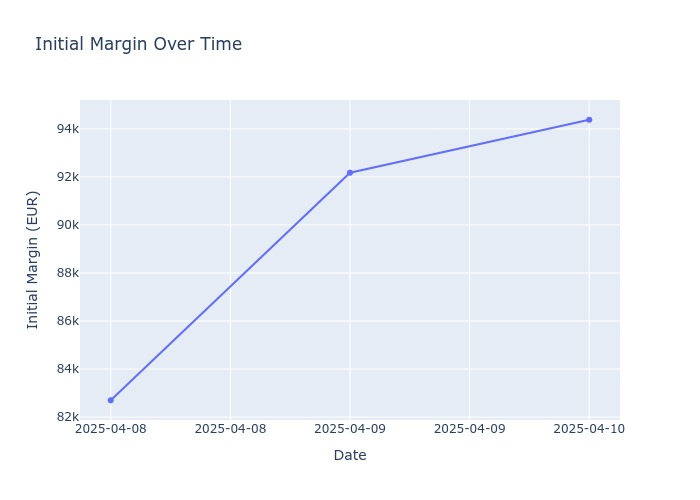

In [16]:
from IPython.display import Image, display

display(Image(filename="../output/initial_margin_graph.jpeg"))

We can see from the output that the initial margins are rising, implicaing that our portfoio is growing in risk, therefore has higher margins.

The output from Excel contains 2 sheets, one for general data about the portfoliofor each business date in date range, and another sheet is used to show the drilldowns.

In [21]:
import pandas as pd

portfolio_margin_df = pd.read_excel("../output/20250408_20250410_SOD_margins.xlsx", sheet_name='portfolio_margin')

portfolio_margin_df

,business_date,initial_margin,liquidation_group,liquidation_group_split,liquidity_addon,long_option_credit,market_risk,market_risk_per_rms_1_rms_components_1_compression_adjustment,market_risk_per_rms_1_rms_components_1_correlation_break_adjustment,market_risk_per_rms_1_rms_components_1_risk_measure_value,...,market_risk_per_rms_3_rms_components_1_compression_adjustment,market_risk_per_rms_3_rms_components_1_correlation_break_adjustment,market_risk_per_rms_3_rms_components_1_risk_measure_value,market_risk_per_rms_3_rms_components_1_subsample_id,market_risk_per_rms_3_rms_market_risk,market_risk_per_rms_3_rms_name,market_risk_per_rms_3_simulation_type,market_risk_per_rms_3_weighting_factor,premium_margin,time_to_expiry_adjustment
0,20250408,82700.040637,PEQ01,PEQ01_HP3,107.049648,0,82592.990989,2583.560563,3314.310426,76695.12,...,0,0,0,1,0,EVENT_RISK_PEQ01,Event,1,348100,0
1,20250409,92173.084949,PEQ01,PEQ01_HP3,119.621607,0,92053.463343,2454.451275,4212.882068,85386.13,...,0,0,0,1,0,EVENT_RISK_PEQ01,Event,1,323200,0
2,20250410,94379.657525,PEQ01,PEQ01_HP3,120.853526,0,94258.803999,2736.729619,4728.964380,86793.11,...,0,0,0,1,0,EVENT_RISK_PEQ01,Event,1,361300,0


In [20]:
drilldowns_df = pd.read_excel("../output/20250408_20250410_SOD_margins.xlsx", sheet_name="drilldowns")

drilldowns_df

,business_date,call_put_flag,component_margin,component_margin_currency,contract_date,exercise_price,iid,line_no,liquidation_group,liquidation_group_split,maturity,net_ls_balance,premium_margin,premium_margin_currency,product_id,version_number
0,20250408,NaN,121248.481202,EUR,20311219,0,49698035,2,PEQ01,PEQ01_HP3,203112,100,0,EUR,FEXD,0
1,20250408,C,-38548.440565,EUR,20311219,100,49683341,3,PEQ01,PEQ01_HP3,203112,-100,348100,EUR,OEXD,0
2,20250409,NaN,124023.284259,EUR,20311219,0,49698035,2,PEQ01,PEQ01_HP3,203112,100,0,EUR,FEXD,0
3,20250409,C,-31850.199309,EUR,20311219,100,49683341,3,PEQ01,PEQ01_HP3,203112,-100,323200,EUR,OEXD,0
4,20250410,NaN,132585.470793,EUR,20311219,0,49698035,2,PEQ01,PEQ01_HP3,203112,100,0,EUR,FEXD,0
5,20250410,C,-38205.813268,EUR,20311219,100,49683341,3,PEQ01,PEQ01_HP3,203112,-100,361300,EUR,OEXD,0


## Error Handling

Errors in `margin_calculator` command are handled similiarly to `etd_portfolio` command, so for in-depth explanation, please check the tutorial for `etd_portoflio`.

## Conclusion

The `margin_calculator` command in the margin estimator tool allows you to:

1. Upload an ETD portfolio from a CSV file
2. Process it for a given range of dates
3. Export the aggregated initial margins in a form of graph and general information about portfolio in Excel

Key features:
- Supports multiple CSV header formats like `etd_portfolio` command
- Allows data range for business days

Ensure your CSV files adhere to one of the supported header formats and contain all required data for accurate margin calculation.